## Final model experiment and evaluation

In [1]:
!pip install stable-baselines3[extra]
!pip install gymnasium[atari]
!pip install ale-py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 105.7 MB/s eta 0:00:0000:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 15.6 MB/s eta 0:00:00


In [3]:
%%writefile train.py
import os
import json
import argparse
import ale_py
import gymnasium as gym

from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import ( EvalCallback, CheckpointCallback, CallbackList,)


# Argument Parser
def parse_args():
    parser = argparse.ArgumentParser(description="Train a DQN agent on an Atari environment.")

    parser.add_argument("--experiment-name", type=str, default="baseline")
    parser.add_argument("--env", type=str, default="ALE/Pong-v5")
    parser.add_argument("--policy", type=str, default="CnnPolicy", choices=["CnnPolicy", "MlpPolicy"])

    parser.add_argument("--timesteps", type=int, default=500_000)
    parser.add_argument("--seed", type=int, default=42)

    parser.add_argument("--lr", type=float, default=1e-4)
    parser.add_argument("--gamma", type=float, default=0.99)
    parser.add_argument("--batch-size", type=int, default=32)
    parser.add_argument("--buffer-size", type=int, default=100_000)
    parser.add_argument("--learning-starts", type=int, default=20_000)

    parser.add_argument("--train-freq", type=int, default=4)
    parser.add_argument("--target-update", type=int, default=10_000)

    parser.add_argument("--eps-start", type=float, default=1.0)
    parser.add_argument("--eps-end", type=float, default=0.05)
    parser.add_argument("--eps-fraction", type=float, default=0.10)

    parser.add_argument("--eval-freq", type=int, default=10_000)
    parser.add_argument("--checkpoint-freq", type=int, default=100_000)

    parser.add_argument("--verbose", type=int, default=0)

    return parser.parse_args()



# Environment Setup
def create_env(env_name, seed, policy):
    if policy == "CnnPolicy":
        env = make_atari_env(env_name, n_envs=1, seed=seed)
        env = VecFrameStack(env, n_stack=4)
    else:
        env = make_vec_env(
            env_name, 
            n_envs=1, 
            seed=seed, 
            env_kwargs={"obs_type": "ram"}
        )

    return env


# DQN Model
def create_model(env, args, log_dir):

    model = DQN(
        policy=args.policy,
        env=env,

        learning_rate=args.lr,
        gamma=args.gamma,

        batch_size=args.batch_size,
        buffer_size=args.buffer_size,
        learning_starts=args.learning_starts,

        train_freq=args.train_freq,
        target_update_interval=args.target_update,

        exploration_initial_eps=args.eps_start,
        exploration_final_eps=args.eps_end,
        exploration_fraction=args.eps_fraction,

        verbose=args.verbose,

        tensorboard_log=log_dir,
    )

    return model


# Custom Evaluation Callback
class CompactEvalCallback(EvalCallback):
    def __init__(self, *args, csv_file=None, **kwargs):
        super().__init__(*args, **kwargs)

        self.csv_file = csv_file

        # Create CSV and write header
        if self.csv_file is not None:
            with open(self.csv_file, "w") as f:
                f.write("timesteps,reward,best_reward,exploration_rate\n")

    def _on_step(self) -> bool:
        continue_training = super()._on_step()

        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:

            print(
                f"[{self.num_timesteps:>7,}] "
                f"Reward: {self.last_mean_reward:>7.2f} | "
                f"Best: {self.best_mean_reward:>7.2f} | "
                f"Exploration: {self.model.exploration_rate:.3f}"
            )

            # Save results to CSV
            if self.csv_file is not None:
                with open(self.csv_file, "a") as f:
                    f.write(
                        f"{self.num_timesteps},"
                        f"{self.last_mean_reward},"
                        f"{self.best_mean_reward},"
                        f"{self.model.exploration_rate}\n"
                    )

        return continue_training

# Training
def train(args):
    base_dir = "/kaggle/working/"

    # assert os.path.isdir("/content/drive/MyDrive"), (
    #     "Google Drive doesn't appear to be mounted. "
    #     "Run drive.mount('/content/drive') in a cell before training."
    # )
    model_dir = os.path.join(base_dir, "models", args.experiment_name)
    log_dir = os.path.join( base_dir, "logs", args.experiment_name, )

    checkpoint_dir = os.path.join(  base_dir, "checkpoints", args.experiment_name, )

    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(log_dir, exist_ok=True)
    os.makedirs(checkpoint_dir, exist_ok=True)

    with open(
        os.path.join(model_dir, "config.json"),
        "w",
    ) as f:

        json.dump(
            vars(args),
            f,
            indent=4,
        )

    env = create_env( args.env, args.seed, args.policy, )

    eval_env = create_env( args.env, args.seed + 100, args.policy, )

    model = create_model( env, args, log_dir,)

    checkpoint_callback = CheckpointCallback(
        save_freq=args.checkpoint_freq,
        save_path=checkpoint_dir,
        name_prefix="dqn_checkpoint",
    )

    eval_callback = CompactEvalCallback(
        eval_env,
        best_model_save_path=model_dir,
        log_path=log_dir,
        eval_freq=args.eval_freq,
        deterministic=True,
        render=False,
        verbose=0,
        n_eval_episodes=10,
    )

    callbacks = CallbackList( [checkpoint_callback, eval_callback,])

    try:
        model.learn(
            total_timesteps=args.timesteps,
            callback=callbacks,
            log_interval=10,
        )

        model.save( os.path.join( model_dir, "dqn_model", ) )

        print("\nTraining completed successfully!")
        print(f"Final model    : {os.path.join(model_dir, 'dqn_model.zip')}")
        print(f"Best model     : {os.path.join(model_dir, 'best_model.zip')}")
        print(f"Config         : {os.path.join(model_dir, 'config.json')}")

    finally:
        env.close()
        eval_env.close()


# Main

def main():
    args = parse_args()
    train(args)


if __name__ == "__main__":
    main()

Overwriting train.py


In [4]:
!python train.py --experiment-name final-experiment-1 --policy CnnPolicy --timesteps 1000000 --seed 42 --lr 1.5e-4 --gamma 0.97 --batch-size 256 --buffer-size 100000 --learning-starts 20000 --train-freq 4 --target-update 10000 --eps-start 1.0 --eps-end 0.05 --eps-fraction 0.20

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7b74878023f0> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7b76486b67b0>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {se

# Post-Training Inspection

Checking which experiment log directories are actually present before
loading TensorBoard event files for plotting.

**Note:** Only exp04–exp10 have log folders here — exp01, exp02, and exp03
logs are missing (likely lost when the session/log directory reset between
runs). Their results below come only from the printed training stdout
above, not from the reward/length curves or the final comparison table.

In [5]:
import os

for root, dirs, files in os.walk("/kaggle/working/logs"):
    print(root)
    for f in files:
        print("   ", f)

/kaggle/working/logs
/kaggle/working/logs/final-experiment-1
    evaluations.npz
/kaggle/working/logs/final-experiment-1/DQN_1
    events.out.tfevents.1784479660.9ba8d1bf5ea0.123.0


# Reward & Episode Length Curves 

Plotting the reward and episode-length trends over training for
`final-model`, the best-performing configuration, to visually
confirm the upward trend seen in the printed logs.

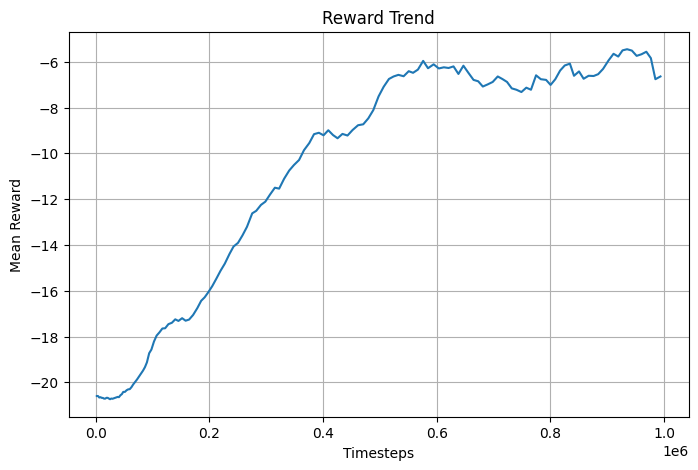

In [6]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt

event_file = "/kaggle/working/logs/final-experiment-1/DQN_1/events.out.tfevents.1784479660.9ba8d1bf5ea0.123.0"

ea = EventAccumulator(event_file)
ea.Reload()

reward_events = ea.Scalars("rollout/ep_rew_mean")

steps = [e.step for e in reward_events]
rewards = [e.value for e in reward_events]

plt.figure(figsize=(8,5))
plt.plot(steps, rewards)
plt.title("Reward Trend")
plt.xlabel("Timesteps")
plt.ylabel("Mean Reward")
plt.grid(True)
plt.show()

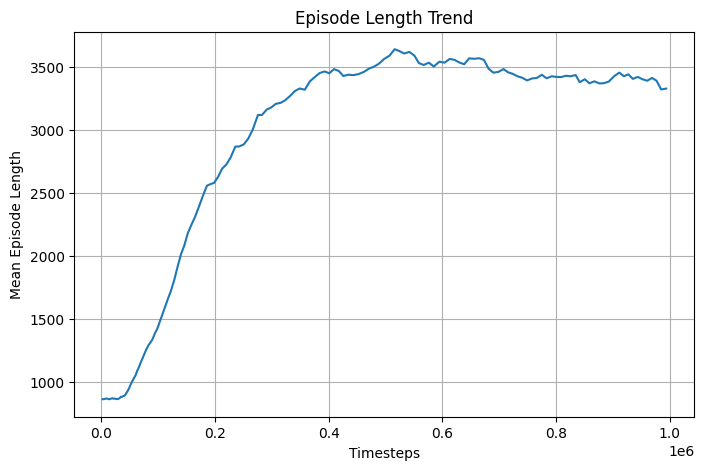

In [7]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt

event_file = "/kaggle/working/logs/final-experiment-1/DQN_1/events.out.tfevents.1784479660.9ba8d1bf5ea0.123.0"

ea = EventAccumulator(event_file)
ea.Reload()

reward_events = ea.Scalars("rollout/ep_len_mean")

steps = [e.step for e in reward_events]
rewards = [e.value for e in reward_events]

plt.figure(figsize=(8,5))
plt.plot(steps, rewards)
plt.title("Episode Length Trend")
plt.xlabel("Timesteps")
plt.ylabel("Mean Episode Length")
plt.grid(True)
plt.show()

# Evaluation

In [17]:
%%writefile play.py
"""
play.py

Load a trained DQN model and watch it play using the greedy policy (deterministic=True).

Examples
--------
# Watch the CNN agent play
python play.py --policy cnn --model models/baseline/dqn_model.zip

# Watch the CNN agent and save an MP4 video
python play.py --policy cnn --model models/baseline/dqn_model.zip --record

# Watch the MLP (RAM) agent play
python play.py --policy mlp --model models/mlp/dqn_model.zip
"""


import argparse
import os
import time
import ale_py
import gymnasium as gym

from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env, make_vec_env
from stable_baselines3.common.vec_env import VecFrameStack, VecVideoRecorder

PIXEL_ENV = "ALE/Pong-v5"


def parse_args():
    parser = argparse.ArgumentParser(
        description="Evaluate a trained DQN Atari agent.")
    parser.add_argument(
        "--policy", choices=["cnn", "mlp"], default="cnn", help="Policy used during training.")
    parser.add_argument("--model", type=str, required=True,
                        help="Path to the trained model (.zip).")
    parser.add_argument("--episodes", type=int, default=5,
                        help="Number of episodes to play.")
    parser.add_argument("--fps", type=int, default=60, help="Playback speed.")
    parser.add_argument("--record", action="store_true",
                        help="Record gameplay to an MP4 (CNN only).")
    return parser.parse_args()


def build_render_env(policy, record=False):
    render_mode = "rgb_array" if record else "human"

    if policy == "cnn":
        env = make_atari_env(PIXEL_ENV, n_envs=1, seed=42,
                             env_kwargs={"render_mode": render_mode})
        env = VecFrameStack(env, n_stack=4)

        if record:
            os.makedirs("videos", exist_ok=True)
            env = VecVideoRecorder(
                env,
                video_folder="videos",
                record_video_trigger=lambda step: step == 0,
                video_length=5000,
                name_prefix="dqn-play",
            )
    else:
        if record:
            print(
                "\nWarning: Video recording is only supported for CNN (pixel-based) environments.")
            print("Continuing with standard human rendering configuration...\n")
            render_mode = "human"

        env = make_vec_env(PIXEL_ENV, n_envs=1, seed=42, env_kwargs={
                        "obs_type": "ram", "render_mode": render_mode})

    return env


def main():
    args = parse_args()
    if not os.path.exists(args.model):
        raise FileNotFoundError(f"\nModel not found:\n{args.model}")

    print("=" * 65)
    print("Deep Q-Network Greedy Evaluation")
    print("=" * 65)
    print(f"Policy     : {args.policy.upper()}")
    print(f"Model      : {args.model}")
    print(f"Episodes   : {args.episodes}")
    print(f"Recording  : {args.record if args.policy == 'cnn' else False}")
    print("=" * 65)

    env = build_render_env(args.policy, record=args.record)
    model = DQN.load(args.model, env=env)
    print("\nModel loaded successfully.\n")

    fps_delay = 1 / args.fps
    all_rewards = []

    try:
        for episode in range(args.episodes):
            obs = env.reset()
            done = False
            episode_reward = 0
            episode_steps = 0

            while not done:
                # Greedy Action Selection (GreedyQPolicy implementation requirement)
                action, _ = model.predict(obs, deterministic=True)

                # VecEnvs automatically step through vector formats arrays
                obs, reward, dones, info = env.step(action)

                done = dones[0]
                episode_reward += reward[0]
                episode_steps += 1

                # VecVideoRecorder handles rendering internally if recording
                if not (args.record and args.policy == "cnn"):
                    env.render()

                time.sleep(fps_delay)

            all_rewards.append(episode_reward)
            print(
                f"Episode {episode + 1:>2} | Reward = {episode_reward:>6.1f} | Steps = {episode_steps}")

    finally:
        env.close()

    print("\n" + "=" * 65)
    print("Evaluation Summary")
    print("=" * 65)
    print(f"Episodes Played : {len(all_rewards)}")
    print(f"Average Reward  : {sum(all_rewards)/len(all_rewards):.2f}")
    print(f"Best Reward     : {max(all_rewards):.2f}")
    print(f"Worst Reward    : {min(all_rewards):.2f}")

    if args.record and args.policy == "cnn":
        print("\nGameplay video saved in: videos/")
    print("\nDone!")


if __name__ == "__main__":
    main()

Overwriting play.py


In [18]:
!python play.py --policy cnn --model /kaggle/working/models/final-experiment-1/best_model.zip --record

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
Deep Q-Network Greedy Evaluation
Policy     : CNN
Model      : /kaggle/working/models/final-experiment-1/best_model.zip
Episodes   : 5
Recording  : True
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]

Model loaded successfully.

Episode  1 | Reward =  -11.0 | Steps = 869
Episode  2 | Reward =   -4.0 | Steps = 914
Episode  3 | Reward =   -8.0 | Steps = 901
Episode  4 | Reward =   -4.0 | Steps = 1173
Saving video to /kaggle/working/videos/dqn-play-step-0-to-step-50